_Neural Data Science_

Lecturer: Prof. Dr. Philipp Berens, Dr. Jan Lause

Tutors: Jonas Beck, Kyra Kadhim, Jonathan Oesterle, Julius Würzler

Summer term 2026

Student names: <span style='background: yellow'>*FILL IN YOUR NAMES HERE* </span>

LLM Disclaimer: <span style='background: yellow'>*Did you use an LLM to solve this exercise? If yes, which one and where did you use it? [Copilot, Claude, ChatGPT, etc.]* </span>

# Neural Data Science Project — Spike Inference

## Inferring spiking activity from calcium imaging data using deep learning

In this project you will train your own deep network to infer neuronal spiking activity from calcium imaging ΔF/F traces. You will work with ground truth data from simultaneous calcium imaging and electrophysiology recordings, preprocess it for training, build and train a neural network, and evaluate your model on held-out neurons.

You are free to use tools, resources and libraries as you see fit. Use comments and markdown cells to document your thought process and to explain your reasoning. We encourage you to compare different algorithms or to implement state of the art solutions. The notebook should be self contained, although you may offload some functions to a `utils.py`. The notebook should be concluded with a final summary / conclusions section.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import resample
from scipy.stats import pearsonr

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

## Context

### Calcium imaging and spike inference

Two-photon calcium imaging records neural activity by measuring fluorescence of genetically encoded calcium indicators (e.g. GCaMP6f, GCaMP6s). When a neuron fires an action potential, calcium flows into the cell, causing the indicator to fluoresce more brightly. The resulting signal — expressed as **ΔF/F** (relative fluorescence change) — is a noisy, temporally smoothed version of the true spiking activity:

- A single action potential produces a fast rise (~50 ms) followed by a slow exponential decay (~200–1000 ms, depending on the indicator)
- The signal is corrupted by shot noise, neuropil contamination, and motion artifacts
- Multiple spikes in quick succession sum nonlinearly

**Spike inference** (also called deconvolution) is the inverse problem of recovering the underlying spike times or spike rates from the observed ΔF/F traces.

### Cascade as a reference

In this project you will train your own neural network for the task of spike inference, similar to what was done in [**Cascade**](https://github.com/HelmchenLabSoftware/Cascade) (Rupprecht et al., *Nature Neuroscience*, 2021). Cascade trains a simple 1D convolutional network (~50k parameters) on a large database of simultaneous calcium imaging and electrophysiology recordings. A key part of their approach is a noise-matched training procedure that resamples the ground truth data to match the noise level and frame rate of any target recording, making the trained models robust across different experimental conditions. Cascade also provides pretrained models for common configurations that can serve as performance baselines.

You can use their code, preprocessing routines, and pretrained models as a reference. The PyTorch implementation is available at [CascadeTorch](https://github.com/PTRRupprecht/CascadeTorch).

**Paper:** Rupprecht P, Carta S, Hoffmann A, Echizen M, Blot A, Kwan AC, Dan Y, Hofer SB, Kitamura K, Helmchen F\*, Friedrich RW\*. *A database and deep learning toolbox for noise-optimized, generalized spike inference from calcium imaging.* Nature Neuroscience (2021). [Link](https://www.nature.com/articles/s41593-021-00895-5)

### The data

The file `spike_inference_data.npz` contains ground truth recordings from simultaneous calcium imaging and electrophysiology. Each recording provides:

| Field | Description |
|---|---|
| `dff` | ΔF/F fluorescence trace (1D float array) |
| `t` | Time vector in seconds (1D float array) |
| `spikes` | Action potential times in seconds (1D float array) |
| `frame_rates` | Imaging frame rate in Hz (scalar) |
| `datasets` | Source dataset identifier (string) |

The data is split into:

- **Training recordings** (`train_*`): Use these to build your preprocessing pipeline and train your network. They come from 4 ground truth datasets recorded with GCaMP6f and GCaMP6s in mouse visual cortex.
- **Test recordings** (`test_*`): A held-out dataset for final evaluation. Do not use these for training.

All recordings were obtained at ~60 Hz and can be resampled to a lower frame rate (e.g. 30 Hz) during preprocessing.

In [ ]:
# load data
def load_data(path="./data"):
    data = np.load(path + "/spike_inference_data.npz", allow_pickle=True)
    return dict(data)

def print_info(data):
    for key in sorted(data.keys()):
        arr = data[key]
        if arr.dtype == object:
            print(f"  [{key:25s}]  {arr.shape}  (variable-length arrays)")
        else:
            print(f"  [{key:25s}]  {arr.shape}  dtype={arr.dtype}")

data = load_data()

print("Overview of the data")
print_info(data)
print(f"\nTraining datasets: {list(data['train_dataset_names'])}")
print(f"Test datasets:     {list(data['test_dataset_names'])}")
print(f"Training recordings: {len(data['train_dff'])}")
print(f"Test recordings:     {len(data['test_dff'])}")

Overview of the data
  [test_dataset_names       ]  (1,)  dtype=<U17
  [test_datasets            ]  (9,)  (variable-length arrays)
  [test_dff                 ]  (9,)  (variable-length arrays)
  [test_filenames           ]  (9,)  (variable-length arrays)
  [test_frame_rates         ]  (9,)  dtype=float64
  [test_spikes              ]  (9,)  (variable-length arrays)
  [test_t                   ]  (9,)  (variable-length arrays)
  [train_dataset_names      ]  (4,)  dtype=<U36
  [train_datasets           ]  (83,)  (variable-length arrays)
  [train_dff                ]  (83,)  (variable-length arrays)
  [train_filenames          ]  (83,)  (variable-length arrays)
  [train_frame_rates        ]  (83,)  dtype=float64
  [train_spikes             ]  (83,)  (variable-length arrays)
  [train_t                  ]  (83,)  (variable-length arrays)

Training datasets: [np.str_('DS09-GCaMP6f-m-V1'), np.str_('DS10-GCaMP6f-m-V1-neuropil-corrected'), np.str_('DS14-GCaMP6s-m-V1'), np.str_('DS15-GCaMP6s-m-V

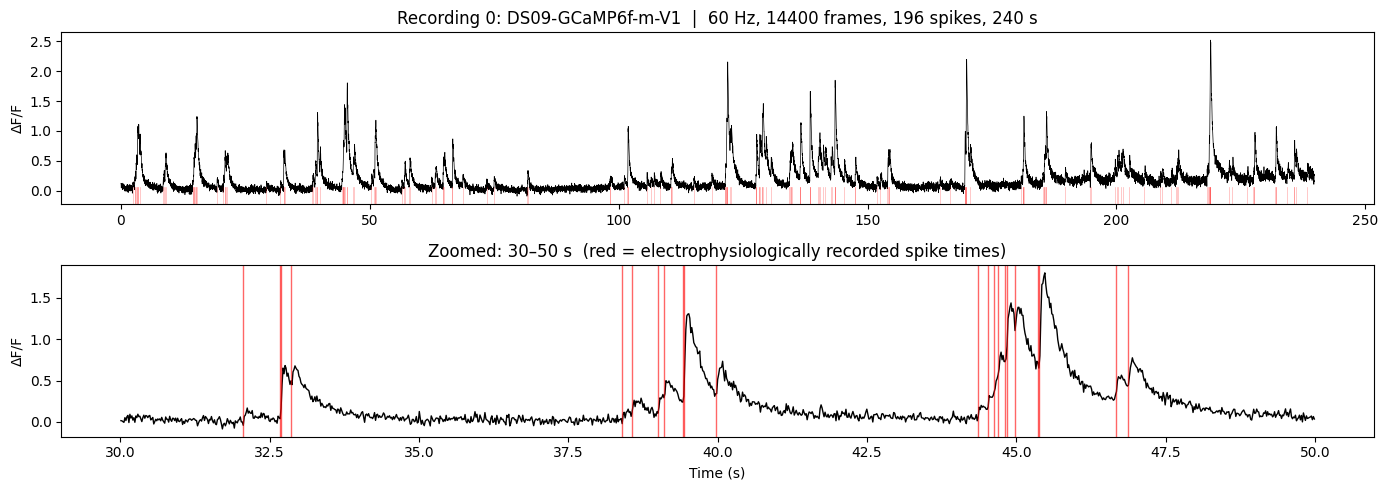

In [4]:
# Visualize an example training recording
idx = 0  # change this to browse different recordings
dff = data['train_dff'][idx]
t = data['train_t'][idx]
spikes = data['train_spikes'][idx]
fr = data['train_frame_rates'][idx]
ds_name = str(data['train_datasets'][idx])

fig, axes = plt.subplots(2, 1, figsize=(14, 5))

# Full trace
axes[0].plot(t, dff, 'k', linewidth=0.5)
for sp in spikes:
    axes[0].axvline(sp, color='red', alpha=0.3, linewidth=0.5, ymin=0, ymax=0.1)
axes[0].set_ylabel('ΔF/F')
axes[0].set_title(f'Recording {idx}: {ds_name}  |  {fr:.0f} Hz, {len(dff)} frames, '
                  f'{len(spikes)} spikes, {t[-1]:.0f} s')

# Zoomed window
t0, t1 = 30, 50
m = (t >= t0) & (t <= t1)
axes[1].plot(t[m], dff[m], 'k', linewidth=1)
for sp in spikes[(spikes >= t0) & (spikes <= t1)]:
    axes[1].axvline(sp, color='red', alpha=0.6, linewidth=1)
axes[1].set_ylabel('ΔF/F')
axes[1].set_xlabel('Time (s)')
axes[1].set_title(f'Zoomed: {t0}–{t1} s  (red = electrophysiologically recorded spike times)')

plt.tight_layout()
plt.show()

## Research question

<span style='background: yellow'>*FILL IN YOUR RESEARCH QUESTION HERE*</span>

Some possible directions (pick one, or formulate your own):

1. **Train a spike inference network and evaluate its generalization.** Build a preprocessing pipeline (resampling, noise augmentation, windowing, target smoothing), train a neural net, and evaluate on the held-out test set. How does performance depend on the training data composition and noise level?

2. **Compare architectures.** Implement at least two different network architectures (e.g. the Cascade default, a deeper/shallower variant, one with skip connections or batch normalization). Which design choices matter most for spike inference performance?

3. **How does temporal smoothing of the ground truth affect inference quality?** Train models with different smoothing kernels (e.g. 25, 50, 100, 200 ms) and evaluate the trade-off between temporal precision and robustness. Optionally compare symmetric vs. causal smoothing kernels.

4. **How well does a network trained on one indicator generalize to another?** Train on GCaMP6f data only and test on GCaMP6s (or vice versa). How much does indicator-specific training improve performance?

Implement all steps necessary to answer your question. Think of: preprocessing, model design, training, evaluation, and visualization. The notebook should be concluded with a summary / conclusions section.